# Breast Cancer Detection Project

1. Import Necessary Libraries

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from ultralytics import YOLO

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

import multiprocessing
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass

print("Libraries imported successfully")

Libraries imported successfully


2. Device Configuration

In [3]:
def setup_device():
    """Configure device for MacBook Air M4 10-core GPU"""
    
    # Check for MPS (Metal Performance Shaders) - Apple's GPU acceleration
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Using Apple MPS (Metal) GPU acceleration")
        
        # MPS specific settings for stability
        torch.mps.set_per_process_memory_fraction(0.8)  # Use 70% of GPU memory
        
        # MPS currently has some limitations with certain operations
        print("  Note: Some operations may fall back to CPU for compatibility")
        
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
        
    else:
        device = torch.device("cpu")
        print("ℹ️ Using CPU (no GPU acceleration found)")
        
    return device

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        # MPS doesn't have a dedicated seed function, but we set torch seed
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initialize
set_seed(42)
device = setup_device()

✅ Using Apple MPS (Metal) GPU acceleration
  Note: Some operations may fall back to CPU for compatibility


3.  Dataset Structure Analysis & Validation

In [4]:
def analyze_dataset_structure(root_path):
    """Analyze and validate dataset structure"""
    
    root = Path(root_path)
    
    # Check directory structure
    expected_dirs = {
        'benign': 'benign',
        'benign_mask': 'benign_mask', 
        'malignant': 'malignant',
        'malignant_mask': 'malignant_mask'
    }
    
    dataset_info = {}
    
    for dir_name in expected_dirs.values():
        dir_path = root / dir_name
        if dir_path.exists():
            images = list(dir_path.glob("*.png")) + list(dir_path.glob("*.jpg")) + list(dir_path.glob("*.jpeg"))
            dataset_info[dir_name] = {
                'exists': True,
                'count': len(images),
                'sample_files': [f.name for f in images[:5]]
            }
        else:
            dataset_info[dir_name] = {'exists': False, 'count': 0, 'sample_files': []}
    
    # Print summary
    print("\n" + "="*50)
    print("DATASET STRUCTURE ANALYSIS")
    print("="*50)
    
    for dir_name, info in dataset_info.items():
        status = "✅" if info['exists'] else "❌"
        print(f"{status} {dir_name}: {info['count']} images")
    
    # Check for mismatched pairs
    print("\n" + "-"*30)
    print("PAIR VALIDATION")
    print("-"*30)
    
    for category in ['benign', 'malignant']:
        img_dir = root / category
        mask_dir = root / f"{category}_mask"
        
        if img_dir.exists() and mask_dir.exists():
            img_files = {f.stem for f in img_dir.glob("*.png") if not f.name.startswith('._')}
            mask_files = {f.stem.replace('_mask', '') for f in mask_dir.glob("*.png") if not f.name.startswith('._')}
            
            missing_masks = img_files - mask_files
            missing_images = mask_files - img_files
            
            print(f"\n{category.upper()}:")
            print(f"  Images: {len(img_files)}, Masks: {len(mask_files)}")
            print(f"  Missing masks: {len(missing_masks)}")
            print(f"  Missing images: {len(missing_images)}")
            
            if len(missing_masks) > 5:
                print(f"  Example missing: {list(missing_masks)[:3]}")
    
    return dataset_info

# Run analysis
root_path = Path("../../dataset/BUSI_Jpeg")
dataset_info = analyze_dataset_structure(root_path)


DATASET STRUCTURE ANALYSIS
✅ benign: 437 images
✅ benign_mask: 454 images
✅ malignant: 210 images
✅ malignant_mask: 211 images

------------------------------
PAIR VALIDATION
------------------------------

BENIGN:
  Images: 437, Masks: 454
  Missing masks: 0
  Missing images: 17

MALIGNANT:
  Images: 210, Masks: 211
  Missing masks: 0
  Missing images: 1


4.  Build Paired Dataset with Quality Control

In [5]:
def validate_mask_quality(mask):
    """Check mask quality metrics"""
    if mask is None:
        return {'valid': False, 'reason': 'None mask'}
    
    unique_values = np.unique(mask)
    is_binary = np.all(np.isin(unique_values, [0, 255])) or np.all(np.isin(unique_values, [0, 1]))
    
    # Count non-zero pixels
    positive_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    fill_ratio = positive_pixels / total_pixels
    
    # Check if mask is too small (likely noise)
    if fill_ratio < 0.001:
        return {'valid': False, 'reason': f'Too small (fill ratio: {fill_ratio:.4f})'}
    
    # Check if mask is too large (unlikely for tumors)
    if fill_ratio > 0.8:
        return {'valid': False, 'reason': f'Too large (fill ratio: {fill_ratio:.4f})'}
    
    return {'valid': True, 'fill_ratio': fill_ratio, 'is_binary': is_binary}

def mask_to_bbox(mask):
    """Convert mask to bounding box with validation"""
    if mask is None:
        return None
    
    # Ensure binary mask
    if mask.dtype != np.uint8:
        mask = (mask > 0).astype(np.uint8) * 255
    
    # Find contours for more accurate bounding box
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        # Fallback to direct coordinate extraction
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None
        x1, y1 = xs.min(), ys.min()
        x2, y2 = xs.max(), ys.max()
    else:
        # Use the largest contour (main tumor)
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        x1, y1, x2, y2 = x, y, x + w, y + h
    
    # Validate bounding box
    if x1 >= x2 or y1 >= y2:
        return None
    
    return [int(x1), int(y1), int(x2), int(y2)]

def build_pairs(img_dir, mask_dir, class_name, class_id, min_mask_ratio=0.001):
    """Build paired dataset with quality control"""
    records = []
    
    img_files = sorted([p for p in img_dir.glob("*.[pj][np][g]") if not p.name.startswith("._")])
    
    quality_stats = {'total': 0, 'valid': 0, 'mask_too_small': 0, 'mask_too_large': 0, 
                     'no_mask': 0, 'invalid_bbox': 0}
    
    for img_path in tqdm(img_files, desc=f"Processing {class_name}"):
        quality_stats['total'] += 1
        
        # Find corresponding mask
        stem = img_path.stem
        mask_path = mask_dir / f"{stem}_mask.png"
        
        if not mask_path.exists():
            quality_stats['no_mask'] += 1
            continue
        
        # Load images
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None or mask is None:
            quality_stats['no_mask'] += 1
            continue
        
        # Validate mask quality
        mask_quality = validate_mask_quality(mask)
        if not mask_quality['valid']:
            if 'Too small' in mask_quality['reason']:
                quality_stats['mask_too_small'] += 1
            elif 'Too large' in mask_quality['reason']:
                quality_stats['mask_too_large'] += 1
            continue
        
        # Convert mask to bbox
        bbox = mask_to_bbox(mask)
        
        if bbox is None:
            quality_stats['invalid_bbox'] += 1
            continue
        
        quality_stats['valid'] += 1
        
        records.append({
            "image_path": str(img_path),
            "mask_path": str(mask_path),
            "class_name": class_name,
            "class_id": class_id,
            "bbox_xyxy": bbox,
            "mask_fill_ratio": mask_quality['fill_ratio']
        })
    
    return records, quality_stats

# Build dataset
print("\n" + "="*50)
print("BUILDING DATASET WITH QUALITY CONTROL")
print("="*50)

records = []
all_quality_stats = {}

for class_name, class_id in [("benign", 0), ("malignant", 1)]:
    img_dir = root_path / class_name
    mask_dir = root_path / f"{class_name}_mask"
    
    if img_dir.exists() and mask_dir.exists():
        class_records, stats = build_pairs(img_dir, mask_dir, class_name, class_id)
        records.extend(class_records)
        all_quality_stats[class_name] = stats

# Create DataFrame
df = pd.DataFrame(records)

print("\n" + "="*50)
print("DATASET STATISTICS")
print("="*50)
print(f"Total valid samples: {len(df)}")
print(f"Class distribution:")
print(df["class_name"].value_counts())

print("\n" + "-"*30)
print("QUALITY FILTERING STATISTICS")
print("-"*30)
for class_name, stats in all_quality_stats.items():
    print(f"\n{class_name.upper()}:")
    print(f"  Total images: {stats['total']}")
    print(f"  Valid masks: {stats['valid']} ({stats['valid']/stats['total']*100:.1f}%)")
    print(f"  No mask file: {stats['no_mask']}")
    print(f"  Mask too small: {stats['mask_too_small']}")
    print(f"  Mask too large: {stats['mask_too_large']}")
    print(f"  Invalid bbox: {stats['invalid_bbox']}")

# Display sample
print("\n" + "-"*30)
print("SAMPLE DATA")
print("-"*30)
df.head()


BUILDING DATASET WITH QUALITY CONTROL


Processing malignant: 100%|██████████| 210/210 [00:00<00:00, 231.53it/s]


DATASET STATISTICS
Total valid samples: 647
Class distribution:
class_name
benign       437
malignant    210
Name: count, dtype: int64

------------------------------
QUALITY FILTERING STATISTICS
------------------------------

BENIGN:
  Total images: 437
  Valid masks: 437 (100.0%)
  No mask file: 0
  Mask too small: 0
  Mask too large: 0
  Invalid bbox: 0

MALIGNANT:
  Total images: 210
  Valid masks: 210 (100.0%)
  No mask file: 0
  Mask too small: 0
  Mask too large: 0
  Invalid bbox: 0

------------------------------
SAMPLE DATA
------------------------------


,image_path,mask_path,class_name,class_id,bbox_xyxy,mask_fill_ratio
0,../../dataset/BUSI_Jpeg/benign/benign (1).png,../../dataset/BUSI_Jpeg/benign_mask/benign (1)...,benign,0,"[288, 134, 339, 160]",0.003717
1,../../dataset/BUSI_Jpeg/benign/benign (10).png,../../dataset/BUSI_Jpeg/benign_mask/benign (10...,benign,0,"[24, 67, 233, 264]",0.082387
2,../../dataset/BUSI_Jpeg/benign/benign (100).png,../../dataset/BUSI_Jpeg/benign_mask/benign (10...,benign,0,"[198, 126, 299, 222]",0.046407
3,../../dataset/BUSI_Jpeg/benign/benign (101).png,../../dataset/BUSI_Jpeg/benign_mask/benign (10...,benign,0,"[438, 172, 537, 223]",0.015648
4,../../dataset/BUSI_Jpeg/benign/benign (102).png,../../dataset/BUSI_Jpeg/benign_mask/benign (10...,benign,0,"[264, 53, 450, 178]",0.048759


5. Visualization

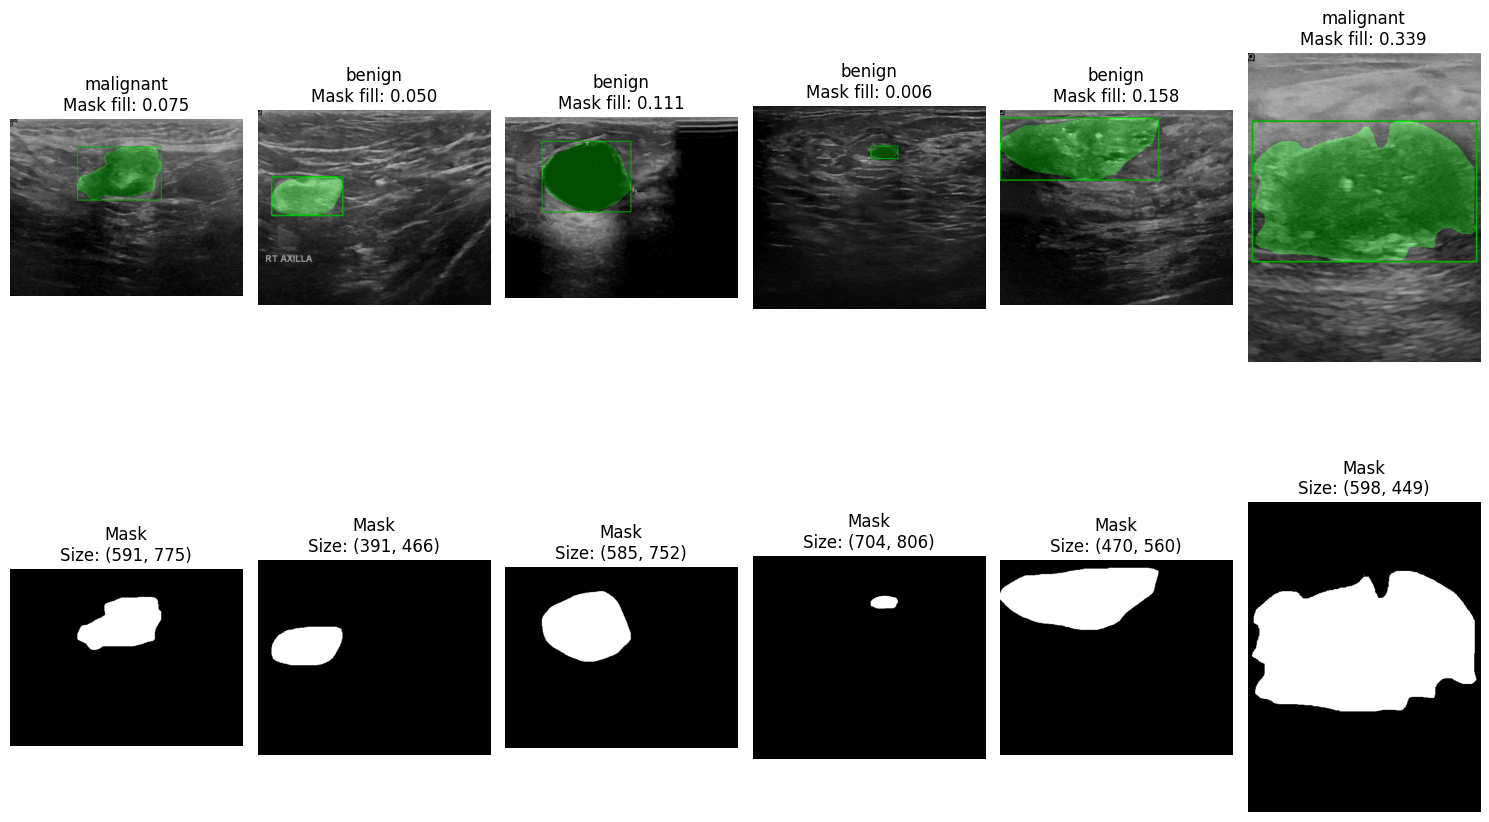


------------------------------
BOUNDING BOX STATISTICS
------------------------------
Bbox width - mean: 269.2, std: 119.9
Bbox height - mean: 157.5, std: 79.2


In [6]:
def visualize_samples(df, num_samples=6, figsize=(15, 10)):
    """Visualize image-mask pairs with bounding boxes"""
    
    sample = df.sample(min(num_samples, len(df)), random_state=42)
    
    fig, axes = plt.subplots(2, num_samples, figsize=figsize)
    if num_samples == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (_, row) in enumerate(sample.iterrows()):
        # Load image
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        
        # Convert to RGB for display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        # Draw bounding box
        x1, y1, x2, y2 = row["bbox_xyxy"]
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Overlay mask with transparency
        mask_overlay = np.zeros_like(img_rgb)
        mask_overlay[:, :, 1] = mask  # Green channel for mask
        img_rgb = cv2.addWeighted(img_rgb, 0.7, mask_overlay, 0.3, 0)
        
        # Display image with bbox
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"{row['class_name']}\nMask fill: {row['mask_fill_ratio']:.3f}")
        axes[0, i].axis("off")
        
        # Display mask only
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f"Mask\nSize: {mask.shape}")
        axes[1, i].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "-"*30)
    print("BOUNDING BOX STATISTICS")
    print("-"*30)
    bbox_widths = [row["bbox_xyxy"][2] - row["bbox_xyxy"][0] for _, row in sample.iterrows()]
    bbox_heights = [row["bbox_xyxy"][3] - row["bbox_xyxy"][1] for _, row in sample.iterrows()]
    print(f"Bbox width - mean: {np.mean(bbox_widths):.1f}, std: {np.std(bbox_widths):.1f}")
    print(f"Bbox height - mean: {np.mean(bbox_heights):.1f}, std: {np.std(bbox_heights):.1f}")

# Visualize
visualize_samples(df)

6. YOLO Dataset Configuration

In [7]:
def bbox_to_yolo(bbox, img_w, img_h):
    """Convert xyxy bbox to YOLO format (x_center, y_center, width, height)"""
    x1, y1, x2, y2 = bbox
    
    # Normalize coordinates
    x_center = ((x1 + x2) / 2) / img_w
    y_center = ((y1 + y2) / 2) / img_h
    width = (x2 - x1) / img_w
    height = (y2 - y1) / img_h
    
    # Clamp to [0, 1] range
    x_center = np.clip(x_center, 0, 1)
    y_center = np.clip(y_center, 0, 1)
    width = np.clip(width, 1e-6, 1)
    height = np.clip(height, 1e-6, 1)
    
    return [x_center, y_center, width, height]

def prepare_yolo_dataset(df, output_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """Prepare dataset in YOLO format with stratified split"""
    
    output_dir = Path(output_dir)
    
    # Create directories
    for split in ['train', 'val', 'test']:
        (output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    # Stratified split
    train_df, temp_df = train_test_split(
        df, test_size=(1 - train_ratio), stratify=df['class_name'], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=test_ratio/(val_ratio+test_ratio), 
        stratify=temp_df['class_name'], random_state=42
    )
    
    splits = {'train': train_df, 'val': val_df, 'test': test_df}
    
    # Create data.yaml
    data_yaml = {
        'path': str(output_dir.absolute()),
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': 2,
        'names': ['benign', 'malignant']
    }
    
    import yaml
    with open(output_dir / 'data.yaml', 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False)
    
    # Process each split
    for split_name, split_df in splits.items():
        print(f"\nProcessing {split_name} split: {len(split_df)} samples")
        
        for idx, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{split_name}"):
            # Read image
            img = cv2.imread(row["image_path"])
            if img is None:
                print(f"Warning: Could not read {row['image_path']}")
                continue
            
            h, w = img.shape[:2]
            
            # Convert bbox to YOLO format
            yolo_bbox = bbox_to_yolo(row["bbox_xyxy"], w, h)
            
            # Save image
            img_filename = f"{Path(row['image_path']).stem}.png"
            img_output_path = output_dir / split_name / 'images' / img_filename
            cv2.imwrite(str(img_output_path), img)
            
            # Save label
            label_filename = f"{Path(row['image_path']).stem}.txt"
            label_output_path = output_dir / split_name / 'labels' / label_filename
            
            with open(label_output_path, 'w') as f:
                f.write(f"{row['class_id']} {yolo_bbox[0]:.6f} {yolo_bbox[1]:.6f} {yolo_bbox[2]:.6f} {yolo_bbox[3]:.6f}\n")
    
    print("\n" + "="*50)
    print("DATASET PREPARATION COMPLETE")
    print("="*50)
    print(f"Output directory: {output_dir}")
    print("\nDataset split sizes:")
    for split_name, split_df in splits.items():
        print(f"  {split_name}: {len(split_df)} images")
    
    return output_dir / 'data.yaml'

# Prepare dataset
yaml_path = prepare_yolo_dataset(df, '../../dataset/BUSI_Jpeg/yolo_dataset')


Processing train split: 452 samples


train: 100%|██████████| 452/452 [00:03<00:00, 119.21it/s]



Processing val split: 97 samples


val: 100%|██████████| 97/97 [00:00<00:00, 117.34it/s]



Processing test split: 98 samples


test: 100%|██████████| 98/98 [00:00<00:00, 124.06it/s]


DATASET PREPARATION COMPLETE
Output directory: ../../dataset/BUSI_Jpeg/yolo_dataset

Dataset split sizes:
  train: 452 images
  val: 97 images
  test: 98 images


7. YOLO Training with Medical Imaging Best Practices

In [ ]:
def train_yolo_model(yaml_path, device, epochs=120, img_size=640, batch_size=8):
    """
    Train YOLO model with medical imaging specific optimizations
    
    Key considerations for medical imaging:
    1. Conservative augmentation (avoid distorting anatomical features)
    2. Focus on object detection accuracy (high IoU requirement)
    3. Handle class imbalance
    4. Monitor validation metrics closely
    """
    
    # Load model - use YOLOv8n for speed, YOLOv8m for accuracy
    model = YOLO('yolo26n.pt')  # Nano model for faster training on M4
    
    # Convert device string to torch device if needed
    if isinstance(device, torch.device):
        device_str = str(device)
    else:
        device_str = device
    
    # Training arguments optimized for medical imaging
    results = model.train(
        data=str(yaml_path),
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        device=device_str,
        
        # Optimizer settings
        optimizer='AdamW',
        lr0=0.001,           # Initial learning rate
        lrf=0.01,            # Final learning rate factor
        momentum=0.937,
        weight_decay=0.0005,
        
        # Medical imaging specific augmentations (conservative)
        hsv_h=0.015,         # Hue augmentation (minimal - preserve tissue color)
        hsv_s=0.7,           # Saturation augmentation
        hsv_v=0.4,           # Value augmentation
        degrees=0.0,         # No rotation (tumors can be any orientation)
        translate=0.1,       # Small translation
        scale=0.5,           # Scale augmentation (0.5x to 1.5x)
        shear=0.0,           # No shear (preserves shape)
        perspective=0.0,     # No perspective (preserves shape)
        flipud=0.0,          # No vertical flip
        fliplr=0.5,          # Horizontal flip (symmetry)
        mosaic=0.0,          # Disable mosaic (can create unrealistic medical images)
        mixup=0.0,           # Disable mixup (can create unrealistic medical images)
        
        # Loss weights (increase box loss for better localization)
        box=7.5,             # Box loss weight (increased for better IoU)
        cls=0.5,             # Class loss weight
        dfl=1.5,             # Distribution focal loss
        
        # Training strategy
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        
        # Regularization
        dropout=0.1,
        
        # Validation and checkpointing
        val=True,
        save=True,
        save_period=10,
        plots=True,
        
        # Performance
        workers=8,
        verbose=True,
        exist_ok=True,
        
        # Early stopping
        patience=30,
        
        # Seed for reproducibility
        seed=42
    )
    
    return model, results

# Train the model
print("\n" + "="*50)
print("TRAINING YOLO MODEL")
print("="*50)

# Check for existing trained model
best_model_path = Path("../train/weights/best.pt")

if best_model_path.exists():
    print(f"\n✅ Loading existing model from {best_model_path}")
    model = YOLO(str(best_model_path))
    print("Model loaded successfully. Skipping training.")
else:
    print("\n" + "="*50)
    print("TRAINING YOLO MODEL")
    print("="*50)
    
    # Train the model
    model, results = train_yolo_model(yaml_path, device, epochs=100, img_size=640, batch_size=4)


TRAINING YOLO MODEL

✅ Loading existing model from ../../runs/detect/train/weights/best.pt
Model loaded successfully. Skipping training.


9. Model Evaluation


MODEL EVALUATION
Found 98 test images


Loading test data: 100%|██████████| 98/98 [00:00<00:00, 345.36it/s]



Loaded 98 test samples (each row is one bounding box)


Evaluating: 100%|██████████| 98/98 [00:04<00:00, 19.62img/s]


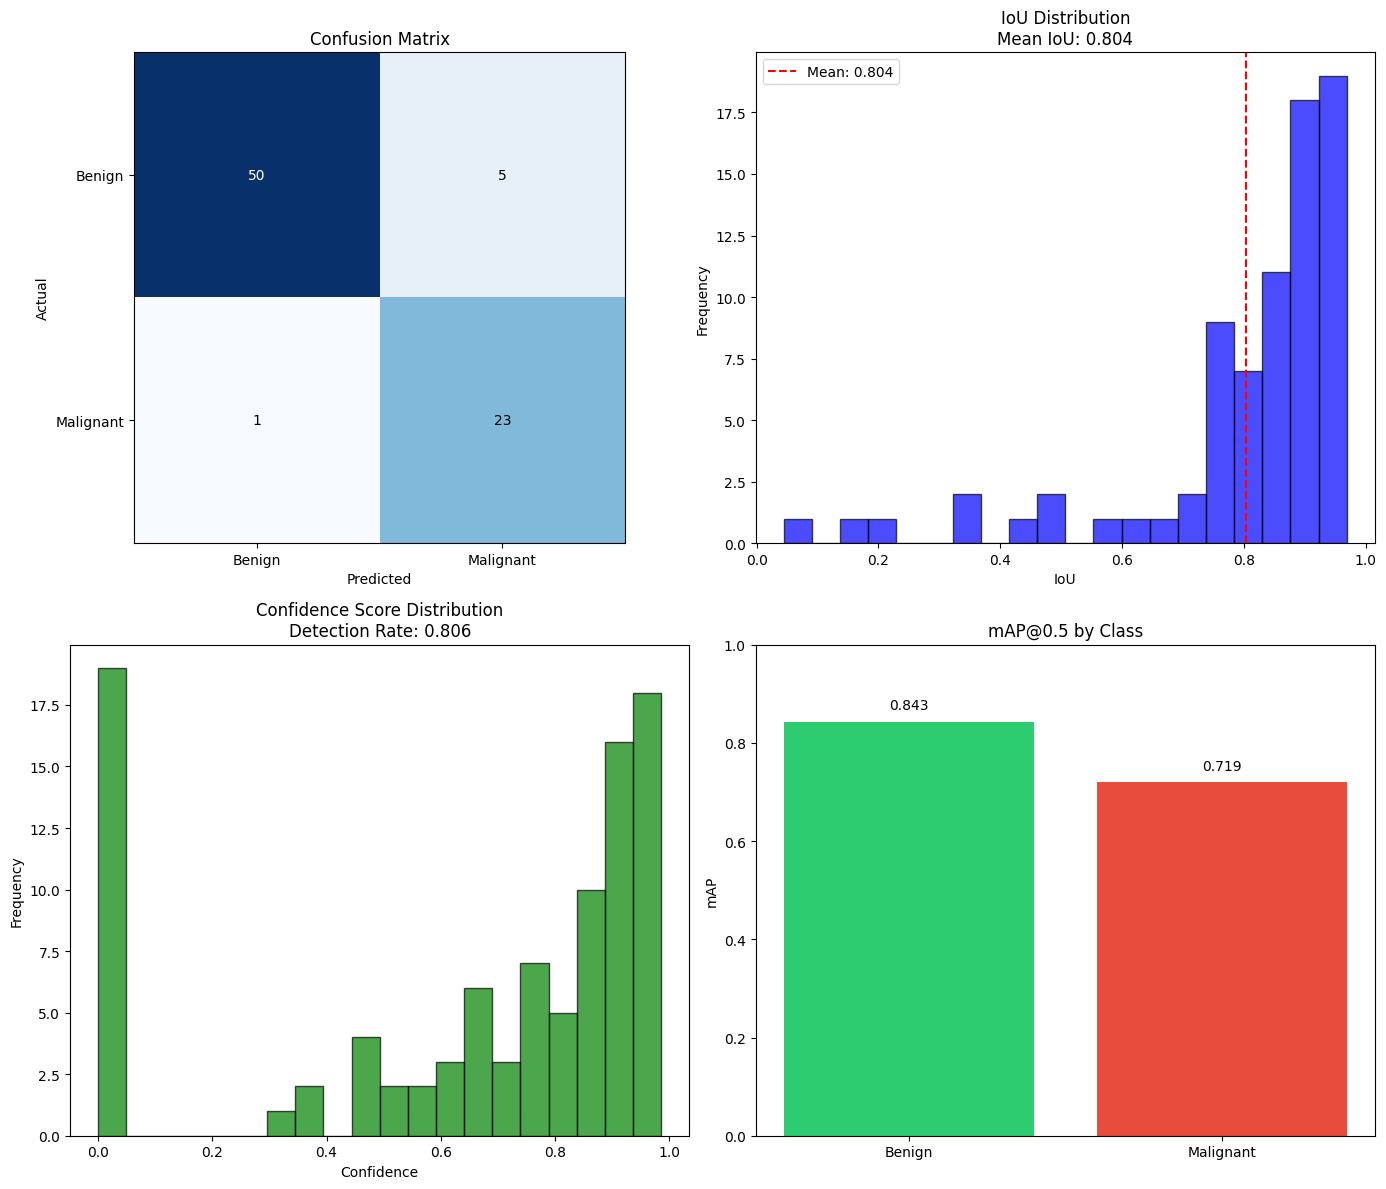


EVALUATION SUMMARY
Overall Detection Rate: 80.61%
Mean IoU (detected): 0.804
Mean Confidence: 0.799

Classification Report:
  Benign - Precision: 0.980
  Benign - Recall: 0.909
  Benign - F1: 0.943
  Malignant - Precision: 0.821
  Malignant - Recall: 0.958
  Malignant - F1: 0.885
  Overall Accuracy: 0.924


In [9]:
import logging
# Suppress YOLO's verbose output
logging.getLogger("ultralytics").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


def load_yolo_test_data(test_images_dir, test_labels_dir):
    """
    Load test data from YOLO format directories
    
    Args:
        test_images_dir: Path to test images
        test_labels_dir: Path to test labels (.txt files)
    
    Returns:
        DataFrame with image_path, bbox_xyxy, class_id
    """
    test_images_dir = Path(test_images_dir)
    test_labels_dir = Path(test_labels_dir)
    
    test_data = []
    
    # Get all image files
    image_files = list(test_images_dir.glob("*.png")) + \
                  list(test_images_dir.glob("*.jpg")) + \
                  list(test_images_dir.glob("*.jpeg"))
    
    print(f"Found {len(image_files)} test images")
    
    for img_path in tqdm(image_files, desc="Loading test data"):
        # Find corresponding label file
        label_path = test_labels_dir / f"{img_path.stem}.txt"
        
        if not label_path.exists():
            print(f"Warning: No label found for {img_path.name}")
            continue
        
        # Read image to get dimensions
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        
        h, w = img.shape[:2]
        
        # Read YOLO format label
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            width = float(parts[3]) * w
            height = float(parts[4]) * h
            
            # Convert YOLO format to xyxy
            x1 = int(x_center - width / 2)
            y1 = int(y_center - height / 2)
            x2 = int(x_center + width / 2)
            y2 = int(y_center + height / 2)
            
            test_data.append({
                "image_path": str(img_path),
                "class_id": class_id,
                "class_name": "malignant" if class_id == 1 else "benign",
                "bbox_xyxy": [x1, y1, x2, y2]
            })
    
    return pd.DataFrame(test_data)


def evaluate_model_yolo_format(model, test_df, device, conf_threshold=0.25, iou_threshold=0.5):
    """
    Evaluate model with test data in YOLO format
    """
    
    y_true = []
    y_pred = []
    iou_scores = []
    confidence_scores = []
    predictions = []
    
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating", unit="img"):
        # Load image
        img = cv2.imread(row["image_path"])
        if img is None:
            continue
        
        # Ground truth
        gt_bbox = row["bbox_xyxy"]
        gt_class = row["class_id"]
        
        # Run inference
        results = model(img, conf=conf_threshold, iou=iou_threshold, device=str(device), verbose=False)
        
        if len(results[0].boxes) > 0:
            # Get highest confidence detection
            pred_box = results[0].boxes.xyxy[0].cpu().numpy()
            pred_conf = results[0].boxes.conf[0].cpu().numpy()
            pred_class = int(results[0].boxes.cls[0].cpu().numpy())
            
            predictions.append(pred_class)
            confidence_scores.append(pred_conf)
            
            # Calculate IoU
            iou = calculate_iou(gt_bbox, pred_box)
            iou_scores.append(iou)
            
            y_true.append(gt_class)
            y_pred.append(pred_class)
        else:
            predictions.append(-1)
            confidence_scores.append(0)
            iou_scores.append(0)
            y_true.append(gt_class)
            y_pred.append(1 - gt_class) if gt_class in [0, 1] else y_pred.append(-1)
    
    # Calculate metrics
    metrics = {}
    
    # Classification metrics
    valid_idx = [i for i, p in enumerate(predictions) if p in [0, 1]]
    if valid_idx:
        metrics['classification_report'] = classification_report(
            [y_true[i] for i in valid_idx], 
            [predictions[i] for i in valid_idx],
            target_names=['benign', 'malignant'],
            output_dict=True
        )
        cm = confusion_matrix([y_true[i] for i in valid_idx], [predictions[i] for i in valid_idx])
        metrics['confusion_matrix'] = cm
    
    # Detection metrics
    detections = [c for c in confidence_scores if c > 0]
    metrics['detection_rate'] = len(detections) / len(test_df) if len(test_df) > 0 else 0
    metrics['mean_confidence'] = np.mean(detections) if detections else 0
    metrics['mean_iou'] = np.mean([iou for iou in iou_scores if iou > 0]) if any(iou > 0 for iou in iou_scores) else 0
    
    # Per-class IoU
    for class_id, class_name in [(0, 'benign'), (1, 'malignant')]:
        class_iou = [iou for i, iou in enumerate(iou_scores) if y_true[i] == class_id and iou > 0]
        metrics[f'mAP@0.5_{class_name}'] = np.mean(class_iou) if class_iou else 0
    
    return metrics, y_true, y_pred, predictions, iou_scores, confidence_scores


def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0


def plot_evaluation_results(metrics, y_true, y_pred, iou_scores, confidence_scores):
    """Create comprehensive evaluation plots"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Confusion Matrix
    if 'confusion_matrix' in metrics:
        cm = metrics['confusion_matrix']
        axes[0, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        axes[0, 0].set_title('Confusion Matrix')
        axes[0, 0].set_xlabel('Predicted')
        axes[0, 0].set_ylabel('Actual')
        
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                axes[0, 0].text(j, i, f'{cm[i, j]}', 
                               ha="center", va="center",
                               color="white" if cm[i, j] > cm.max() / 2 else "black")
        
        axes[0, 0].set_xticks([0, 1])
        axes[0, 0].set_yticks([0, 1])
        axes[0, 0].set_xticklabels(['Benign', 'Malignant'])
        axes[0, 0].set_yticklabels(['Benign', 'Malignant'])
    
    # 2. IoU Distribution
    positive_iou = [iou for iou in iou_scores if iou > 0]
    if positive_iou:
        axes[0, 1].hist(positive_iou, bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0, 1].set_title(f'IoU Distribution\nMean IoU: {metrics["mean_iou"]:.3f}')
        axes[0, 1].set_xlabel('IoU')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].axvline(x=metrics['mean_iou'], color='red', linestyle='--', label=f'Mean: {metrics["mean_iou"]:.3f}')
        axes[0, 1].legend()
    else:
        axes[0, 1].text(0.5, 0.5, 'No detections with IoU > 0', 
                       ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('IoU Distribution')
    
    # 3. Confidence Distribution
    axes[1, 0].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].set_title(f'Confidence Score Distribution\nDetection Rate: {metrics["detection_rate"]:.3f}')
    axes[1, 0].set_xlabel('Confidence')
    axes[1, 0].set_ylabel('Frequency')
    
    # 4. Per-class Performance
    class_names = ['Benign', 'Malignant']
    map_values = [metrics.get(f'mAP@0.5_{name.lower()}', 0) for name in class_names]
    bars = axes[1, 1].bar(class_names, map_values, color=['#2ecc71', '#e74c3c'])
    axes[1, 1].set_title('mAP@0.5 by Class')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].set_ylim(0, 1)
    
    for bar, value in zip(bars, map_values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                        f'{value:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("EVALUATION SUMMARY")
    print("="*50)
    print(f"Overall Detection Rate: {metrics['detection_rate']:.2%}")
    print(f"Mean IoU (detected): {metrics['mean_iou']:.3f}")
    print(f"Mean Confidence: {metrics['mean_confidence']:.3f}")
    
    if 'classification_report' in metrics:
        print("\nClassification Report:")
        print(f"  Benign - Precision: {metrics['classification_report']['benign']['precision']:.3f}")
        print(f"  Benign - Recall: {metrics['classification_report']['benign']['recall']:.3f}")
        print(f"  Benign - F1: {metrics['classification_report']['benign']['f1-score']:.3f}")
        print(f"  Malignant - Precision: {metrics['classification_report']['malignant']['precision']:.3f}")
        print(f"  Malignant - Recall: {metrics['classification_report']['malignant']['recall']:.3f}")
        print(f"  Malignant - F1: {metrics['classification_report']['malignant']['f1-score']:.3f}")
        print(f"  Overall Accuracy: {metrics['classification_report']['accuracy']:.3f}")


# ============================================
# RUN EVALUATION
# ============================================

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Set paths to your test data
test_images_dir = "../../dataset/BUSI_Jpeg/yolo_dataset/test/images"
test_labels_dir = "../../dataset/BUSI_Jpeg/yolo_dataset/test/labels"

# Load test data from YOLO format
test_df = load_yolo_test_data(test_images_dir, test_labels_dir)
print(f"\nLoaded {len(test_df)} test samples (each row is one bounding box)")

# Run evaluation
metrics, y_true, y_pred, predictions, iou_scores, confidence_scores = evaluate_model_yolo_format(
    model, test_df, device, conf_threshold=0.25, iou_threshold=0.5
)

# Plot results
plot_evaluation_results(metrics, y_true, y_pred, iou_scores, confidence_scores)

In [10]:
# Save model (optional)
model.export(format='onnx')
print("\n✅ Model exported to ONNX format")


✅ Model exported to ONNX format


10. Inference Function for Clinical Use

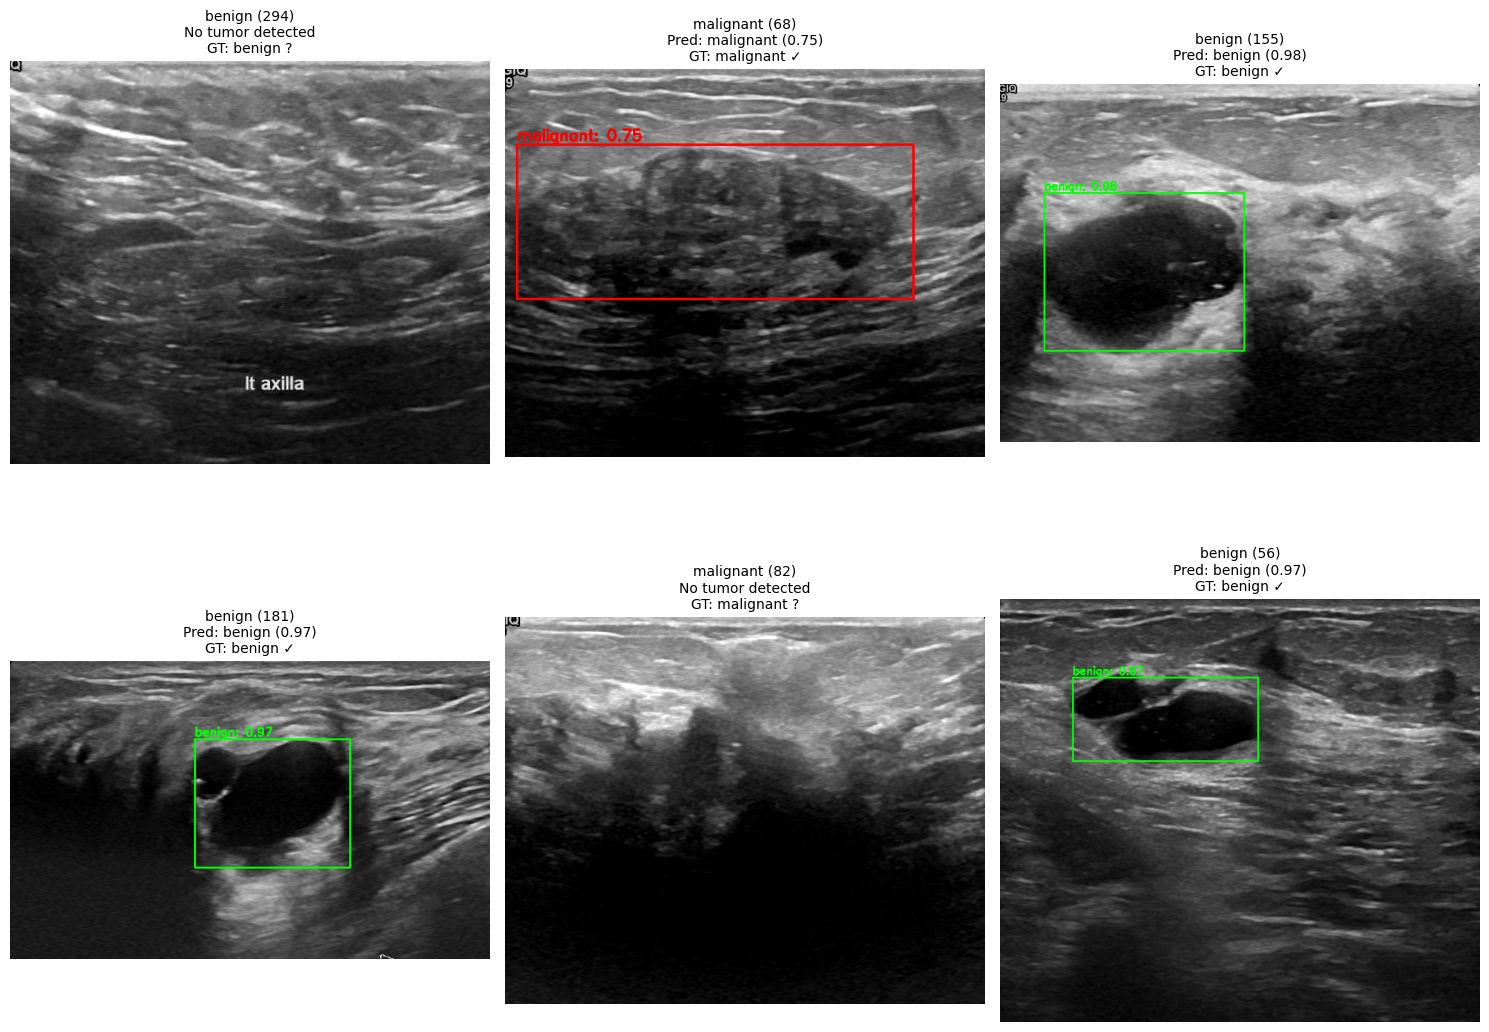


MULTI-IMAGE PREDICTION SUMMARY
Tested 6 images from ../../dataset/BUSI_Jpeg/yolo_dataset/test/images
Detection rate: 4/6
Accuracy (with GT): 4/6

Detailed Results:
------------------------------------------------------------
  benign (294)                             | Pred: No detection | Conf: 0.000 | GT: benign
✓ malignant (68)                           | Pred: malignant  | Conf: 0.753 | GT: malignant
✓ benign (155)                             | Pred: benign     | Conf: 0.982 | GT: benign
✓ benign (181)                             | Pred: benign     | Conf: 0.972 | GT: benign
  malignant (82)                           | Pred: No detection | Conf: 0.000 | GT: malignant
✓ benign (56)                              | Pred: benign     | Conf: 0.973 | GT: benign


In [11]:
def predict_tumor(image_path, model, conf_threshold=0.5, device=device):
    """
    Run inference on a single breast ultrasound image
    
    Returns:
    - image with bounding box
    - prediction (class, confidence, bbox)
    """
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Run inference
    results = model(img, conf=conf_threshold, device=device, verbose=False)
    
    # Process results
    detections = []
    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            class_name = 'malignant' if cls == 1 else 'benign'
            
            detections.append({
                'bbox': [int(x1), int(y1), int(x2), int(y2)],
                'confidence': float(conf),
                'class': class_name,
                'class_id': cls
            })
            
            # Draw bounding box
            color = (255, 0, 0) if cls == 1 else (0, 255, 0)  # Red for malignant, Green for benign
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
            label = f"{class_name}: {conf:.2f}"
            cv2.putText(img_rgb, label, (int(x1), int(y1)-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    return img_rgb, detections


def predict_multiple_images(model, test_images_dir, num_images=5, conf_threshold=0.5, device=device, figsize=(15, 12)):
    """
    Test multiple random images from the test set
    
    Parameters:
    - model: trained YOLO model
    - test_images_dir: path to test images directory
    - num_images: number of random images to test
    - conf_threshold: confidence threshold for detections
    - device: device to run inference on
    - figsize: figure size for display
    
    Returns:
    - results: list of dictionaries with image path, detections, and ground truth (if available)
    """
    
    # Get all test images
    test_images = list(Path(test_images_dir).glob("*.png")) + \
                  list(Path(test_images_dir).glob("*.jpg")) + \
                  list(Path(test_images_dir).glob("*.jpeg"))
    
    if len(test_images) == 0:
        print(f"No images found in {test_images_dir}")
        return []
    
    # Randomly select images
    num_images = min(num_images, len(test_images))
    selected_images = random.sample(test_images, num_images)
    
    results = []
    
    # Calculate grid dimensions
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if num_images == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Process each image
    for idx, img_path in enumerate(selected_images):
        # Run prediction
        result_img, detections = predict_tumor(str(img_path), model, conf_threshold, device)
        
        # Try to extract ground truth from filename (if available)
        gt_class = None
        filename = img_path.stem
        if 'benign' in filename.lower():
            gt_class = 'benign'
        elif 'malignant' in filename.lower():
            gt_class = 'malignant'
        
        # Store results
        results.append({
            'image_path': str(img_path),
            'filename': filename,
            'detections': detections,
            'ground_truth': gt_class,
            'prediction': detections[0]['class'] if detections else 'No detection',
            'confidence': detections[0]['confidence'] if detections else 0
        })
        
        # Display image
        axes[idx].imshow(result_img)
        axes[idx].axis('off')
        
        # Create title
        title = f"{filename}\n"
        if detections:
            title += f"Pred: {detections[0]['class']} ({detections[0]['confidence']:.2f})"
        else:
            title += "No tumor detected"
        
        if gt_class:
            correct = detections and detections[0]['class'] == gt_class if detections else False
            status = "✓" if correct else "✗" if detections else "?"
            title += f"\nGT: {gt_class} {status}"
        
        axes[idx].set_title(title, fontsize=10)
    
    # Hide unused subplots
    for idx in range(len(selected_images), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("MULTI-IMAGE PREDICTION SUMMARY")
    print("="*60)
    print(f"Tested {len(selected_images)} images from {test_images_dir}")
    print(f"Detection rate: {sum(1 for r in results if r['detections'])}/{len(results)}")
    
    # Calculate accuracy if ground truth available
    if any(r['ground_truth'] for r in results):
        correct = sum(1 for r in results if r['detections'] and r['detections'][0]['class'] == r['ground_truth'])
        print(f"Accuracy (with GT): {correct}/{sum(1 for r in results if r['ground_truth'])}")
    
    print("\nDetailed Results:")
    print("-"*60)
    for r in results:
        status = "✓" if (r['detections'] and r['ground_truth'] and r['detections'][0]['class'] == r['ground_truth']) else " "
        print(f"{status} {r['filename'][:40]:<40} | Pred: {r['prediction']:<10} | Conf: {r['confidence']:.3f} | GT: {r['ground_truth'] or 'N/A'}")
    
    return results


# Test images
test_images_dir = "../../dataset/BUSI_Jpeg/yolo_dataset/test/images"
results = predict_multiple_images(model, test_images_dir, num_images=6, conf_threshold=0.5, device=str(device))
